<a href="https://colab.research.google.com/github/SAMAD-KHAN03/ml/blob/master/algorithms/SVMs/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

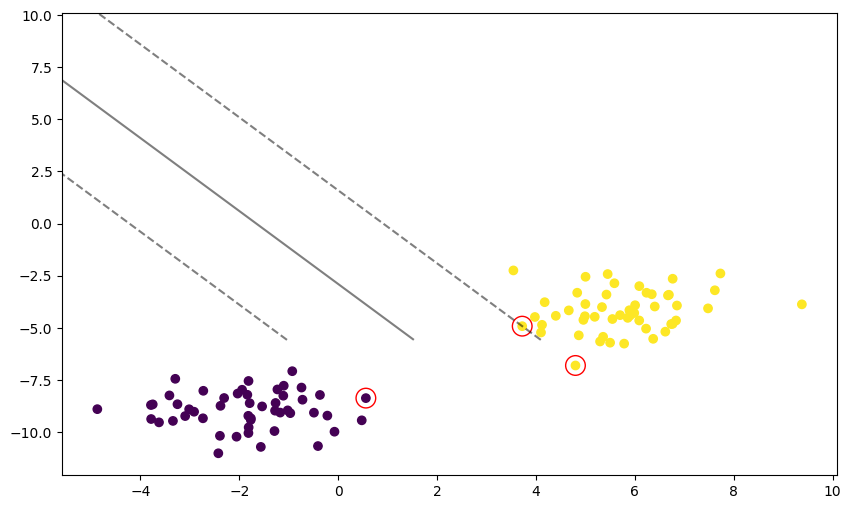

In [13]:
from sklearn.svm import SVC
X,Y=datasets.make_blobs(n_samples=100,n_features=2,centers=2,cluster_std=1.05,random_state=40)
model=SVC(kernel='linear')
model.fit(X,Y)
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=Y)
plt.scatter(model.support_vectors_[:,0],model.support_vectors_[:,1],s=200,linewidth=1,facecolors='none',edgecolors='r')
ax=plt.gca()
xlim=ax.get_xlim()
xx=np.linspace(xlim[0],xlim[1],30)
yy=np.linspace(xlim[0],xlim[1],30)
YY,XX=np.meshgrid(yy,xx)
xy=np.vstack([XX.ravel(),YY.ravel()]).T
Z=model.decision_function(xy).reshape(XX.shape)
plt.contour(XX,YY,Z,colors='k',levels=[-1,0,1],alpha=0.5,linestyles=['--','-','--'])

plt.show()


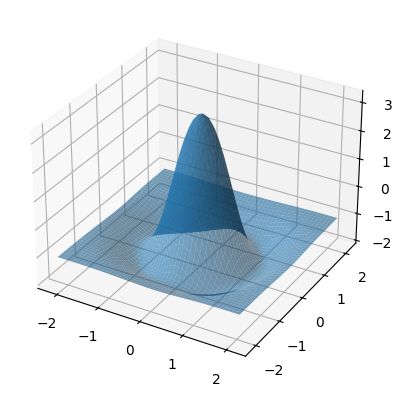

In [1]:
# !pip install scikit-learn matplotlib numpy -q

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from mpl_toolkits.mplot3d import Axes3D

# 1 Create non-linear dataset
X, y = make_circles(n_samples=200, factor=0.5, noise=0.1, random_state=42)

# 2 Train SVM with RBF kernel
model = SVC(kernel='rbf', gamma=2)
model.fit(X, y)

# 3 Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                     np.linspace(y_min, y_max, 50))

# 4 Compute decision function (distance from hyperplane)
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5 3D Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot surface
ax.plot_surface(xx, yy, Z, alpha=0.6)

# (Optional) If you want to actually render the plot when running locally:
# plt.show()